#📘 Week 2 Assignment — Machine Learning & Time Series Analysis

Topics Covered: Exploratory Data Analysis (EDA) · Feature Engineering · Linear Regression · Cross Validation · Hyperparameter Tuning · Random Forest · Time Series Analysis · ADF Stationarity Test · Forecasting

#Importing libraries.

In [67]:
# Import required libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import (
    cross_val_score,
    GridSearchCV
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from statsmodels.tsa.stattools import adfuller

#1. Dataset Loading and Quick Review
Loading the dataset to understand its structure before analysis and model training.

In [68]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


**1.1 Shape :** Shows the total number of rows and columns available in the dataset.

In [69]:
print("Shape:")
print(df.shape)

Shape:
(2640, 12)


**1.2 Columns :** Lists all available features and attributes present in the dataset.

In [70]:
print("\nColumns:")

print(df.columns)


Columns:
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')


**1.3 info :** Displays data types and checks for non-null entries.

In [71]:
print("\nInfo:")

df.info()


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


**1.4 Describe :** Provides a statistical summary including mean, standard deviation, minimum, and maximum values.

In [72]:
print("\nDescribe:")

display(df.describe())


Describe:


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


# 2. Missing Values & Duplicate Check

Before building models, the dataset is reviewed for missing values and duplicate records.

In [73]:
print("Missing Values:")

print(df.isnull().sum())

print("\nDuplicate Rows:")

print(df.duplicated().sum())

Missing Values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate Rows:
0


# 3. Exploratory Data Analysis (EDA)

EDA helps uncover trends, relationships, and useful insights from Tesla delivery and production data.

**3.1 Deliveries by Model**

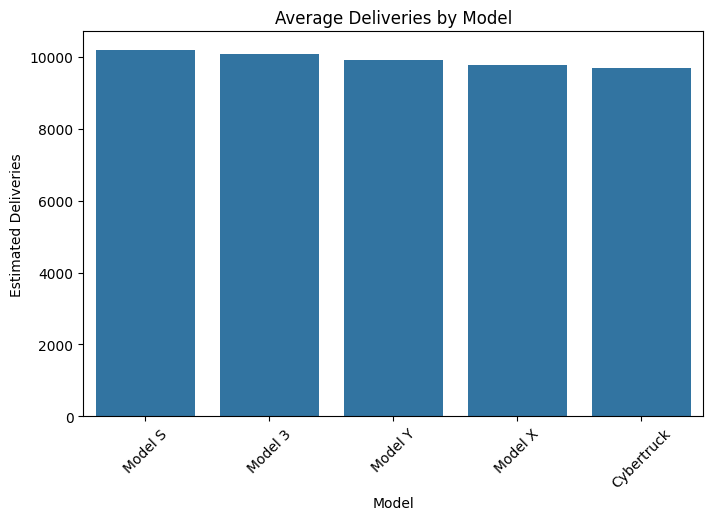

In [74]:
plt.figure(figsize=(8,5))

model_deliveries = (
    df.groupby('Model')['Estimated_Deliveries']
    .mean()
    .sort_values(ascending=False)
)

sns.barplot(x=model_deliveries.index,y=model_deliveries.values)

plt.title('Average Deliveries by Model')

plt.xlabel('Model')

plt.ylabel('Estimated Deliveries')

plt.xticks(rotation=45)

plt.show()

**3.2 Deliveries by Region**

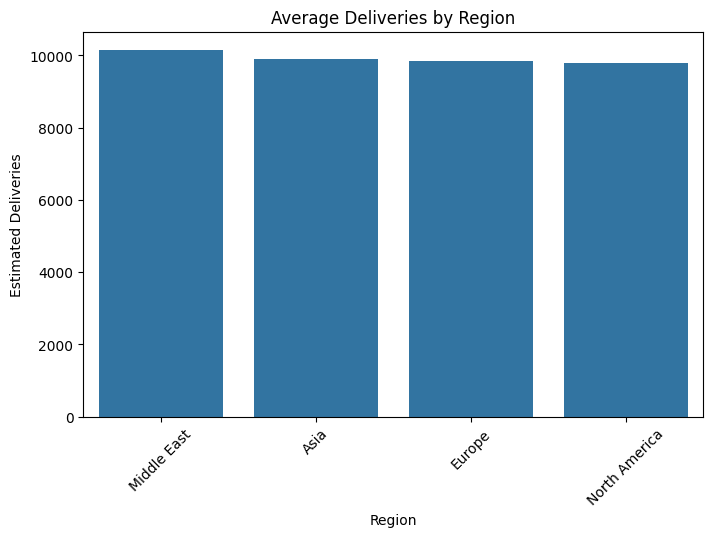

In [75]:
plt.figure(figsize=(8,5))

region_deliveries = (
    df.groupby('Region')['Estimated_Deliveries']
    .mean()
    .sort_values(ascending=False)
)

sns.barplot(x=region_deliveries.index,y=region_deliveries.values)

plt.title('Average Deliveries by Region')

plt.xlabel('Region')

plt.ylabel('Estimated Deliveries')

plt.xticks(rotation=45)

plt.show()

**3.3  Correlation Heatmap**

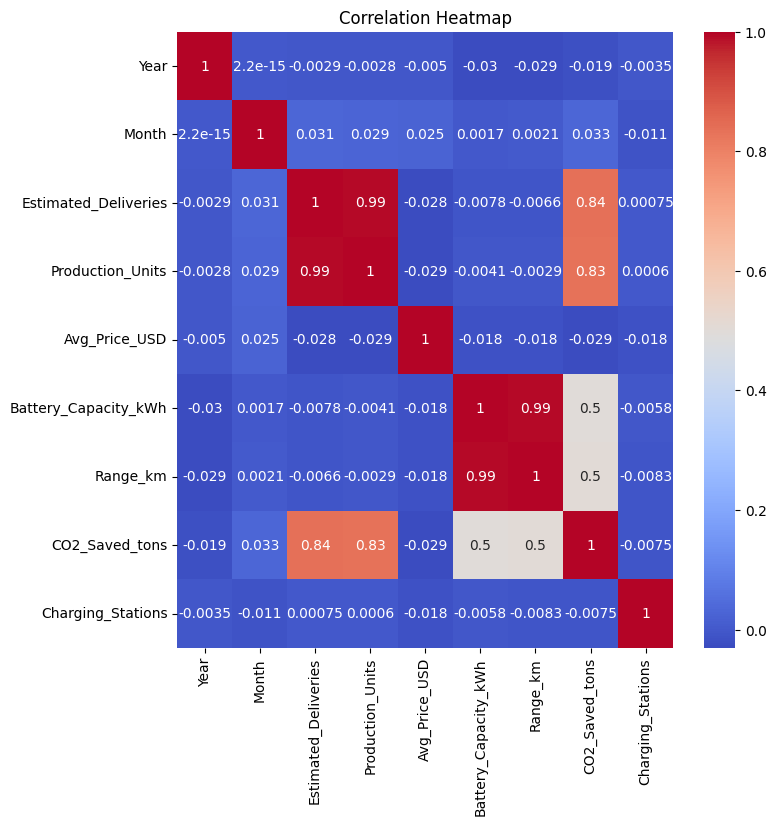

In [76]:
plt.figure(figsize=(8,8))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

 >**Correlation Heatmap Interpretation**

The correlation between Production_Units and Estimated_Deliveries is 0.99, which indicates an extremely strong positive relationship. This means that higher production levels generally lead to higher deliveries.

**3.4 Production vs Deliveries**

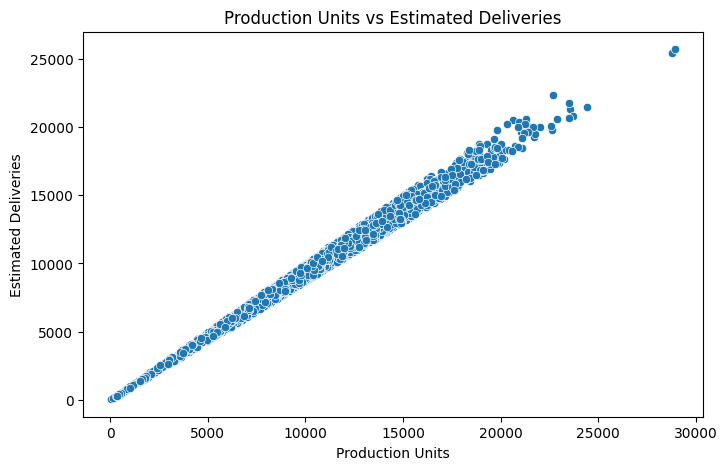

In [77]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Production_Units',
    y='Estimated_Deliveries',
    data=df
)

plt.title(
    'Production Units vs Estimated Deliveries'
)

plt.xlabel('Production Units')

plt.ylabel('Estimated Deliveries')

plt.show()


**3.5 Time Trend Line**

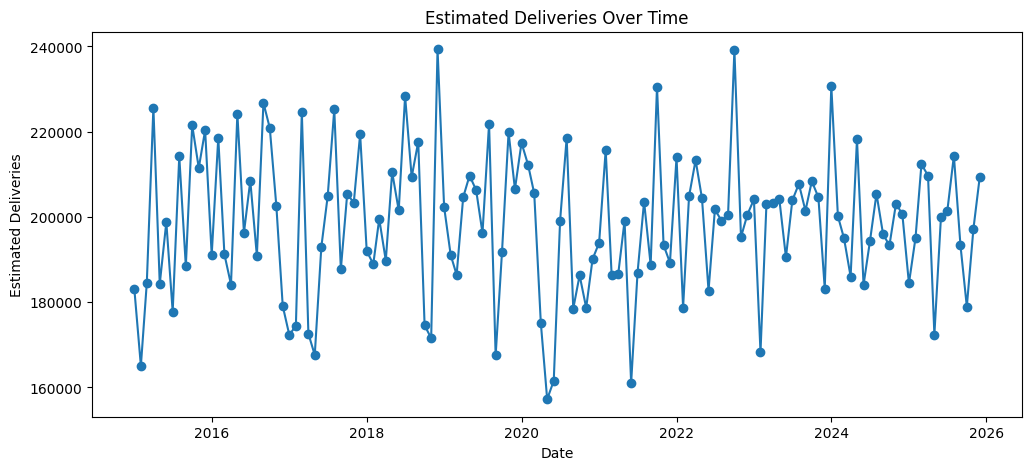

In [78]:
df['Date'] = pd.to_datetime(
    df['Year'].astype(str)
    + '-'
    + df['Month'].astype(str)
)

monthly = df.groupby('Date')['Estimated_Deliveries'].sum()

plt.figure(figsize=(12,5))

plt.plot(
    monthly.index,
    monthly.values,
    marker='o'
)

plt.title(
    'Estimated Deliveries Over Time'
)

plt.xlabel('Date')

plt.ylabel('Estimated Deliveries')

plt.show()


# 4. Feature Engineering


**4.1 Label Encoding**

In [79]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_cols = [
    'Region',
    'Model',
    'Source_Type'
]

for col in categorical_cols:

    df[col] = encoder.fit_transform(
        df[col]
    )

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207,2023-05-01
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640,2015-02-01
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071,2019-01-01
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333,2021-02-01
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722,2016-12-01


**4.2 Create Deliveries_Lag1**

In [80]:
df['Deliveries_Lag1'] = df['Estimated_Deliveries'].shift(1)

df['Deliveries_Lag1'] = df['Deliveries_Lag1'].fillna( df['Deliveries_Lag1'].mean())

**4.3 Create Rolling_Mean_3**

In [81]:
df['Rolling_Mean_3'] = df['Estimated_Deliveries'].rolling(3) .mean()

df['Rolling_Mean_3'] = df['Rolling_Mean_3'].fillna(df['Rolling_Mean_3'].mean())

**4.4 Verify no Nan values remain**

In [82]:
print(df[['Deliveries_Lag1','Rolling_Mean_3'] ].isnull().sum())

Deliveries_Lag1    0
Rolling_Mean_3     0
dtype: int64


>**Feature Engineering Interpretation**

Label encoding was applied to convert categorical variables into numerical values.

Lag features : Deliveries_Lag1 was created using shift(1) this basically gets previous delivery value as feature.

Rolling mean: Rolling_Mean_3 was created to capture recent delivery trends by averaging the last three periods.

These features help the model learn historical patterns and improve prediction accuracy.

# 5. Chronological Split and Linear Regression

5.1 Define X and y ,X being the input y being the output  

In [83]:
X = df.drop(
    ['Estimated_Deliveries', 'Date'],
    axis=1
)

y = df['Estimated_Deliveries']

5.2 Chronological split (80/20)

In [84]:
split = int(len(df) * 0.8)

X_train = X[:split]

X_test = X[split:]

y_train = y[:split]

y_test = y[split:]

print("Train size:", len(X_train))

print("Test size:", len(X_test))

Train size: 2112
Test size: 528


>Chronological split was done instead of train_test_split cause we are working with time - series data.This preserves the order of data, train_test_split wouldve lead to data leakage in training set.


5.3 Train model (linear regresssion model)

In [85]:
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

5.4 Make Predctions

In [86]:
y_pred = model.predict(X_test)

5.5 Evaluate

In [87]:
mae = mean_absolute_error(y_test,y_pred)

rmse = np.sqrt(mean_squared_error( y_test,y_pred ))

r2 = r2_score( y_test,y_pred)

print("MAE:", mae)

print("RMSE:", rmse)

print("R²:", r2)

MAE: 310.3345215398842
RMSE: 375.5646664534478
R²: 0.9908058721380986


5.6 Actual vs Predicted plot

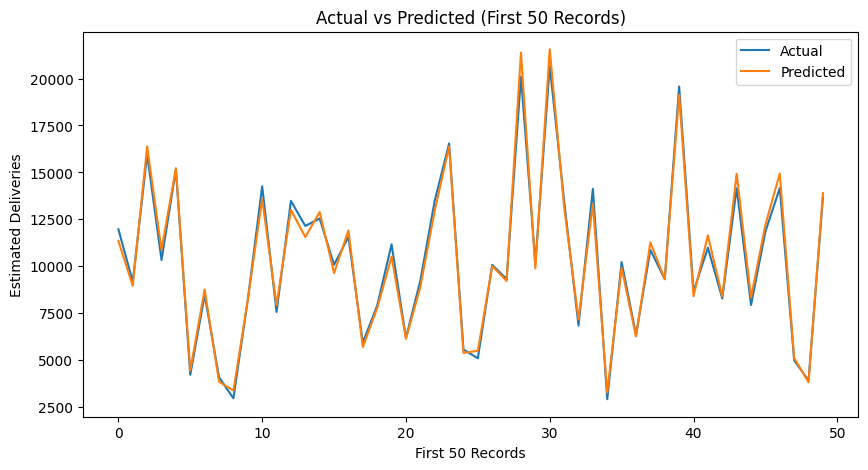

In [88]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:50],label='Actual')

plt.plot(y_pred[:50],label='Predicted')

plt.title( 'Actual vs Predicted (First 50 Records)')

plt.xlabel('First 50 Records')

plt.ylabel('Estimated Deliveries')

plt.legend()

plt.show()

>**Linear Regression Interpretation**

MAE (Mean Absolute Error): 310.33

RMSE (Root Mean Squared Error): 375.56

R² Score: 0.9908

The Linear Regression model achieved excellent predictive performance. An R² score of 0.9908 indicates that the model explains approximately 99% of the variation in Estimated_Deliveries. The low MAE and RMSE values show that the prediction errors are small, indicating that the model predicts delivery values accurately.

# 6. 5-Fold Cross Validation


In [89]:
cv_scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring='r2')

print("Per-Fold R² Scores:")
print(cv_scores)

print("\nMean R²:")
print(cv_scores.mean())

print("\nStandard Deviation:")
print(cv_scores.std())

Per-Fold R² Scores:
[0.99064898 0.99046596 0.98949291 0.99051101 0.99080587]

Mean R²:
0.9903849476659861

Standard Deviation:
0.00046153530925534015


>**Cross Validation Interpretation**

Cross validation is usually performed so that we can run our model on different train and test data so we can select best parameter for future .

5-Fold Cross Validation produced a mean R² score of 0.9904 with a very low standard deviation (0.00046). This indicates that the Linear Regression model is stable and generalizes well across different subsets of the data.




# 7. Random Forest and Hyperparameter Tuning

GridSearchCV is used to find the optimal hyperparameters for RandomForestRegressor. The best model is then evaluated and feature importances are visualized.

7.1 Define parameter grid

In [90]:
param_grid = {'n_estimators': [50, 100],
              'max_depth': [5, 10, None]}

7.2 Run GridSearchCV

In [91]:
grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2'
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [5, 10, None], 'n_estimators': [50, 100]},
             scoring='r2')

 7.3 Best parameters

In [92]:
print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': None, 'n_estimators': 50}


7.4 Best model

In [93]:
rf_model = grid.best_estimator_

rf_pred = rf_model.predict(X_test)

7.5 Evaluate

In [94]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

rf_r2 = r2_score(y_test, rf_pred)

print("MAE:", rf_mae)

print("RMSE:", rf_rmse)

print("R²:", rf_r2)

MAE: 303.85833333333335
RMSE: 388.5512760612014
R²: 0.99015903323468


7.6 Feature Importance Chart

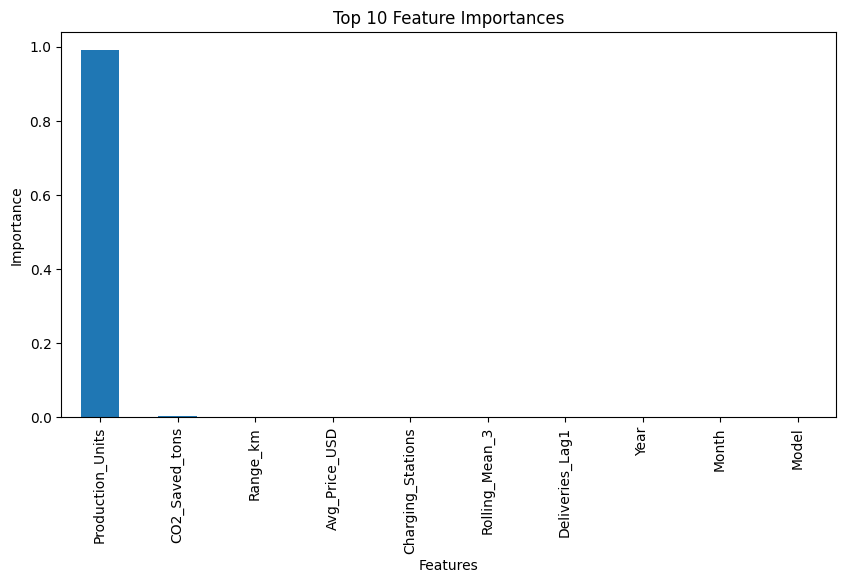

In [95]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,5))

importance.head(10).plot(kind='bar')

plt.title('Top 10 Feature Importances')

plt.xlabel('Features')

plt.ylabel('Importance')

plt.show()

>**Feature Importance chart Interpretation**

Production_Units was identified as the most important feature, indicating that vehicle production has the strongest influence on Estimated_Deliveries. Other features contribute comparatively less to the prediction.

# 8. Augmented Dickey-Fuller (ADF) Test



In [96]:
adf_result = adfuller(df['Estimated_Deliveries'])

print("ADF Statistic:", adf_result[0])

print("p-value:", adf_result[1])

if adf_result[1] < 0.05:
    print("Conclusion: The series is stationary.")

else:
    print("Conclusion: The series is non-stationary.")

ADF Statistic: -53.82661259715622
p-value: 0.0
Conclusion: The series is stationary.


>**ADF Interpretation**

The ADF test is used to determine whether the Estimated_Deliveries time series
is stationary or not.

In ADF you basically first create a null hypothesis-

H0: The Estimated_Deliveries time series is not stationary.

The p-value is 0.0, which is less than 0.05. Therefore, we reject the null hypothesis and conclude that the Estimated_Deliveries time series is stationary.

# 9. Forecast


9.1 Creating a forecast table

In [97]:
forecast = pd.DataFrame({

'Actual': y_test.values[:20],

'Predicted': y_pred[:20]

})

forecast['Error_%'] = abs(

    (forecast['Actual'] - forecast['Predicted'])

    / forecast['Actual']

) * 100

forecast.head(20)

,Actual,Predicted,Error_%
0,11974,11350.249894,5.209204
1,9189,8960.226206,2.489648
2,15956,16390.011572,2.720052
3,10336,10882.323750,5.285640
4,15152,15223.636066,0.472783
5,4224,4453.460471,5.432303
6,8475,8766.438567,3.438803
7,4093,3851.878984,5.891058
8,2972,3385.900162,13.926654
9,8208,8209.196553,0.014578


>**Forecast Interpretation**

The forecast table compares actual and predicted deliveries for the first 20 test records and shows the percentage error for each prediction.

9.2 Comparing the models( Linear regression and Random Forest)

In [98]:
comparison = pd.DataFrame({

'Model':['Linear Regression', 'Random Forest'],

'MAE':[mae, rf_mae],

'RMSE':[rmse, rf_rmse],

'R²':[r2, rf_r2]

})

comparison

,Model,MAE,RMSE,R²
0,Linear Regression,310.334522,375.564666,0.990806
1,Random Forest,303.858333,388.551276,0.990159


>**Model Comparison Interpretation**

Both Linear Regression and Random Forest achieved excellent performance, with R² scores above 0.99.

Linear Regression slightly outperformed Random Forest, achieving an R² score of 0.9908 compared to 0.9901.

The low MAE and RMSE values for both models indicate small prediction errors and high accuracy.

 Overall, Linear Regression was selected as the best-performing model for this dataset due to its slightly better performance and simpler model structure.